***Proyecto 1 - Probabilidad y estadística***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
df = pd.read_excel("visceral_fat.xlsx")
df.head()
df.info()
df.describe() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ethnicity                   133 non-null    int64  
 1   mean diastolic bp (mmhg)    133 non-null    float64
 2   mean systolic bp (mmhg)     133 non-null    float64
 3   central armellini fat (mm)  133 non-null    float64
 4   pregnancies (number)        128 non-null    float64
 5   bmi pregestational (kg/m)   132 non-null    float64
 6   child birth weight (g)      133 non-null    int64  
 7   gestational dm              133 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 8.4 KB


,ethnicity,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),bmi pregestational (kg/m),child birth weight (g),gestational dm
count,133.000000,133.000000,133.000000,133.000000,128.000000,132.000000,133.000000,133.000000
mean,0.443609,70.593985,116.578947,44.230827,2.351562,27.871136,3257.563910,0.135338
std,0.498688,8.657662,13.879602,14.606195,1.686397,6.874268,490.318578,0.343378
min,0.000000,51.500000,90.000000,12.700000,1.000000,15.810000,1105.000000,0.000000
25%,0.000000,64.500000,107.000000,34.600000,1.000000,22.550000,2944.000000,0.000000
50%,0.000000,70.000000,114.000000,42.500000,2.000000,26.260000,3220.000000,0.000000
75%,1.000000,75.500000,125.000000,52.700000,3.000000,30.935000,3610.000000,0.000000
max,1.000000,100.500000,167.000000,94.400000,9.000000,55.360000,4534.000000,1.000000


*Análisis explororatorio*

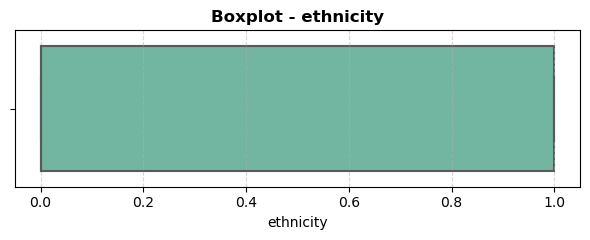

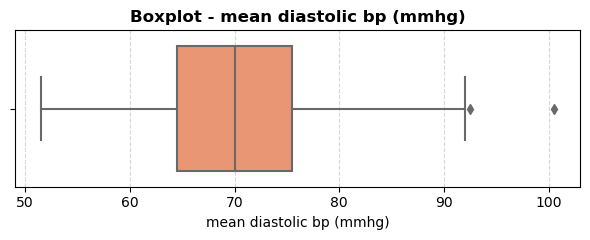

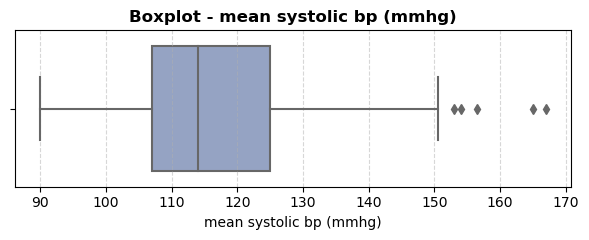

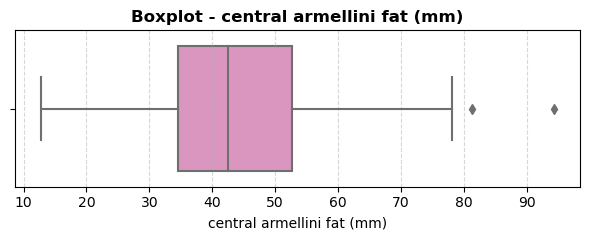

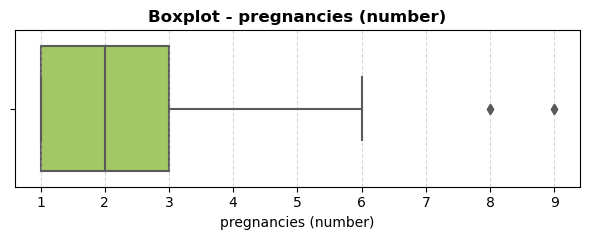

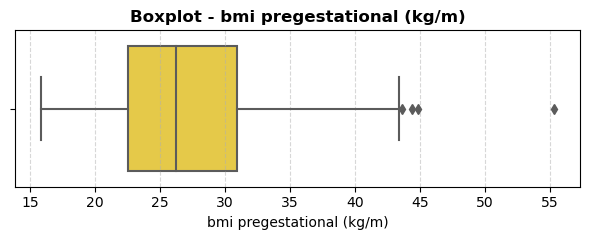

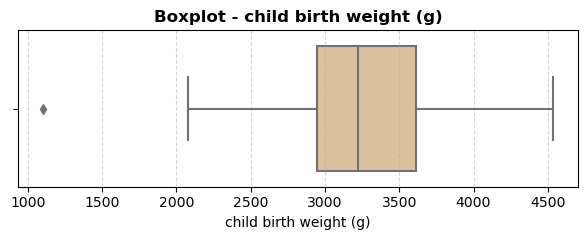

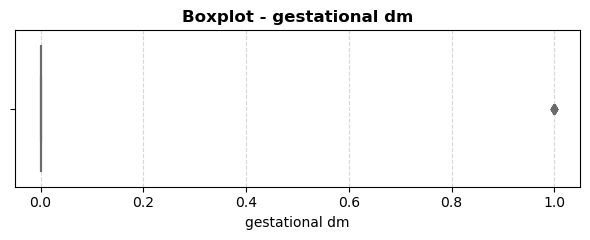

In [3]:
numericas = df.select_dtypes(include=[np.number]).columns

colores = sns.color_palette("Set2", len(numericas))

for i, col in enumerate(numericas):
    plt.figure(figsize=(6,2.5))
    
    sns.boxplot(
        x=df[col],
        color=colores[i],
        linewidth=1.5
    )
    
    plt.title(f'Boxplot - {col}', fontsize=12, weight='bold')
    plt.xlabel(col)
    
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

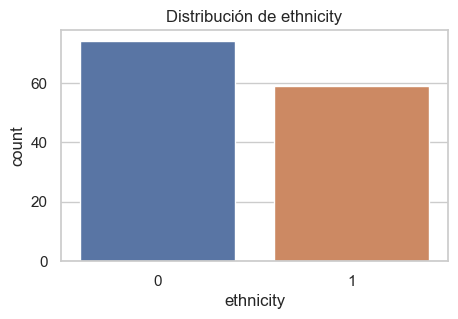

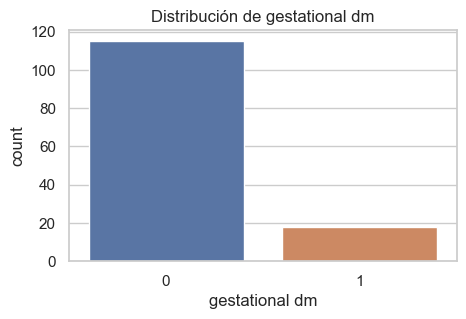

In [6]:
for col in ['ethnicity', 'gestational dm']:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.show()

In [7]:
df.isnull().sum()
df = df.fillna(df.median(numeric_only=True))

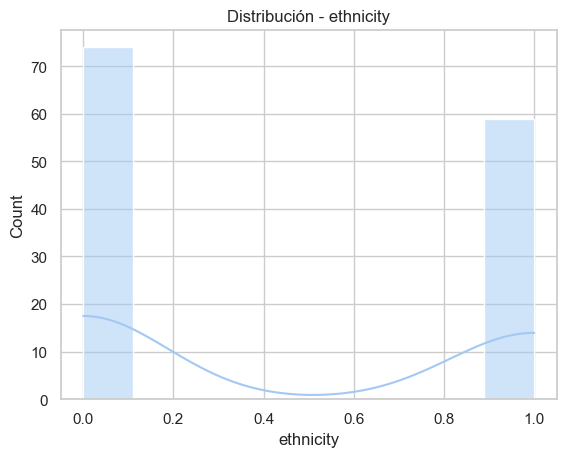

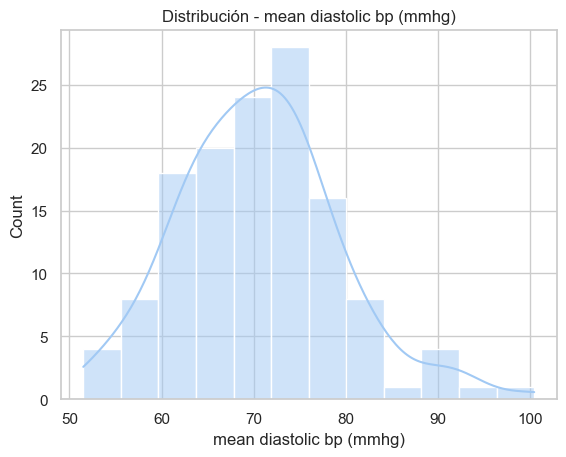

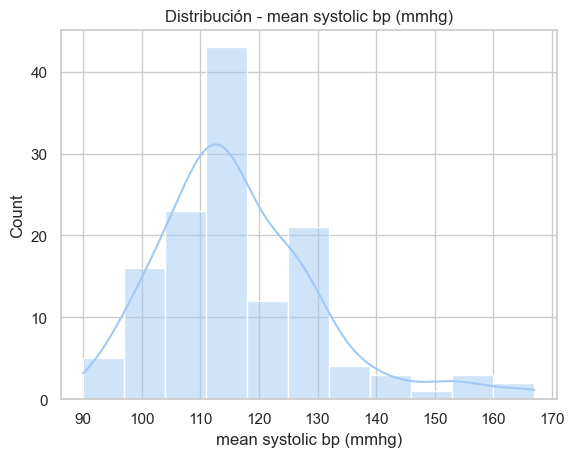

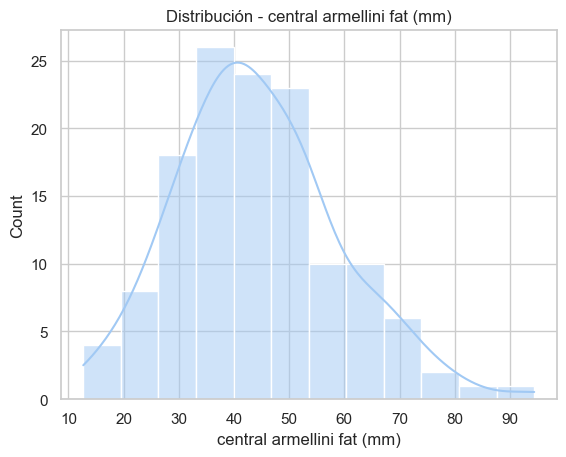

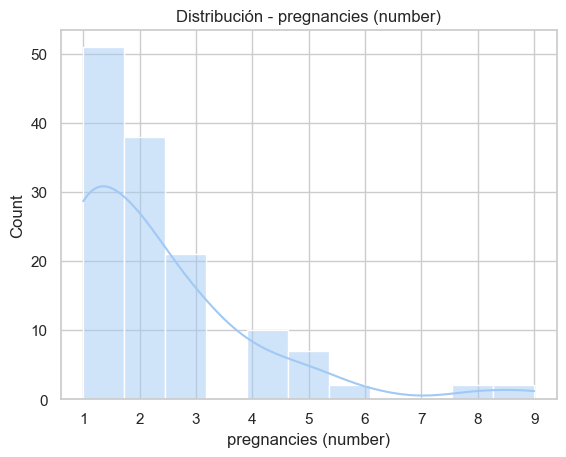

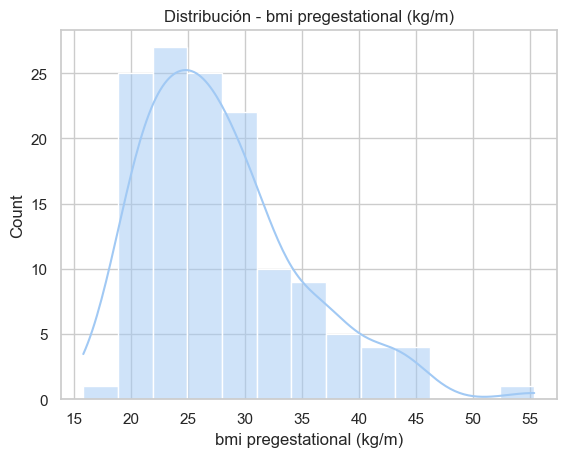

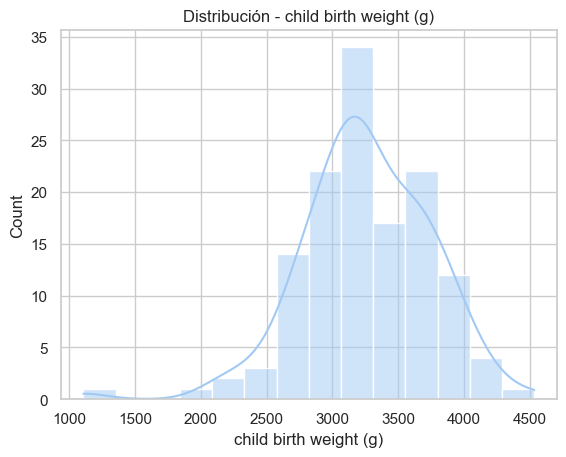

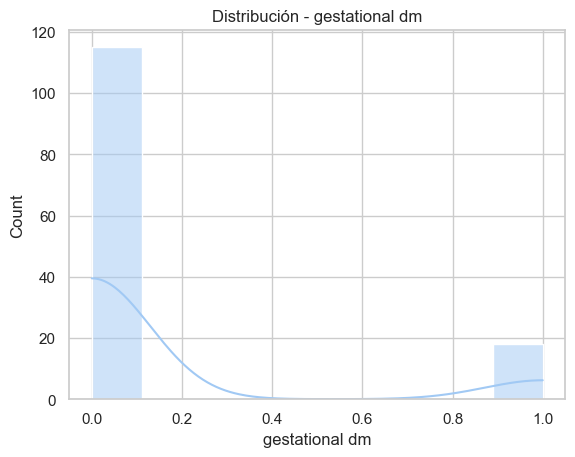

In [11]:
for col in numericas:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución - {col}')
    plt.show()

In [9]:
for col in numericas:
    stat, p = stats.kstest(df[col], 'norm', args=(df[col].mean(), df[col].std()))
    print(col, "p-value:", p)

ethnicity p-value: 8.418993101540925e-17
mean diastolic bp (mmhg) p-value: 0.6399882321482417
mean systolic bp (mmhg) p-value: 0.004880312004145737
central armellini fat (mm) p-value: 0.5705885597297957
pregnancies (number) p-value: 8.078786113957026e-08
bmi pregestational (kg/m) p-value: 0.1074215120471268
child birth weight (g) p-value: 0.688045237189222
gestational dm p-value: 1.087454375216706e-33


Variable normales: t test 

- mean diastolic bp
- central armellini fat
- bmi pregestational
- child birth weight

Variables no normales: U de mann Whitney

- mean systolic bp
- pregnancies

In [13]:
for col in numericas:
    cv = df[col].std() / df[col].mean()
    print(col, "CV:", cv)

ethnicity CV: 1.124161503420653
mean diastolic bp (mmhg) CV: 0.12264022524610928
mean systolic bp (mmhg) CV: 0.1190575308811606
central armellini fat (mm) CV: 0.33022658871897964
pregnancies (number) CV: 0.7079836428995246
bmi pregestational (kg/m) CV: 0.24586663585275176
child birth weight (g) CV: 0.15051694826013245
gestational dm CV: 2.5371814208466756


CV < 0.2 → baja variabilidad

0.2 ≤ CV ≤ 0.5 → variabilidad moderada

CV > 0.5 → alta variabilidad

*Observaciones:*


El número de embarazos destaca por su alta variabilidad, reflejando diferencias importantes entre pacientes. Central armellini fat y bmi pregestational presentan una variabilidad moderada, también hay heterogeneidad moderada entre pacientes. Las variable mean diastolic bp, mean systolic bp y child birth weight presentan baja variabilidad. El coeficiente de variación no es adecuado para variables categóricas como ethnicity y gestational dm porque su media no tiene un significado interpretativo en términos de magnitud.

Las variables con baja variabilidad, como la presión arterial sistólica y diastólica y el peso al nacer, indican que los valores se encuentran relativamente concentrados alrededor de la media; esto sugiere una mayor homogeneidad en la población, esto facilita la comparación entre los grupos y aumenta la estabilidad de estimaciones estadísticas como la media.

Las variables con variabilidad moderada, como el IMC pregestacional y la grasa visceral muestran una heterogeneidad intermedia entre las personas,  esto es esperable en variables biológicas influenciadas por múltiples factores como genéticos, ambientales o de estilo de vida. En estos casos, las comparaciones entre grupos siguen siendo válidas, pero deben interpretarse con mayor cuidado [1].

La presencia de distintos niveles de variabilidad indica que no todas las variables pueden ser tratadas bajo los mismos supuestos estadísticos. En particular, las variables con alta variabilidad o asimetría requieren enfoques más robustos, como transformaciones de los datos o el uso de pruebas no paramétricas, para garantizar la validez de los resultados.


*Observaciones generales:*

Se evidencia que las variables numéricas presentan diferencias importantes en sus escalas, destacándose el peso al nacer como la variable con mayor rango. Además, varias variables muestran indicios de asimetría, particularmente el índice de masa corporal pregestacional, el número de embarazos y la presión arterial sistólica. Esto sugiere que no todas las variables siguen una distribución normal,
Se identificaron valores atípicos en múltiples variables como:
- IMC pregestacional 
- presión arterial 
- número de embarazos 
- peso al nacer

**Tipo de distribución para cada variable**
- mean diastolic bp: Distribución normal, baja variabilidad y un valor p alto 
- child birth weight: distribución proximadamente normal, tiene forma de campana.
- central armellini fat: Distribución muy cercana a normal y más o menos simétrica.
- bmi pregestational: Distribución asimétrica positiva, es decir, se ubserva un sesgo a la derecha.
- mean systolic bp: Distribución asimétrica positiva, cola hacia valores altos.
- pregnancies: Distribución (discreta) asimétrica positiva, se observa concentracion en valores bajos y cola larga.
- Ethnicity y gestational dm son variables categóricas 

El análisis de las distribuciones muestra que solo algunas variables se aproximan a una distribución normal, mientras que otras presentan asimetrías, principalmente hacia la derecha, lo cual es común en variables clínicas [1]. Asimismo, se identificaron variables discretas y categóricas que no siguen distribuciones continuas. Esto es importante para elegir las pruebas 

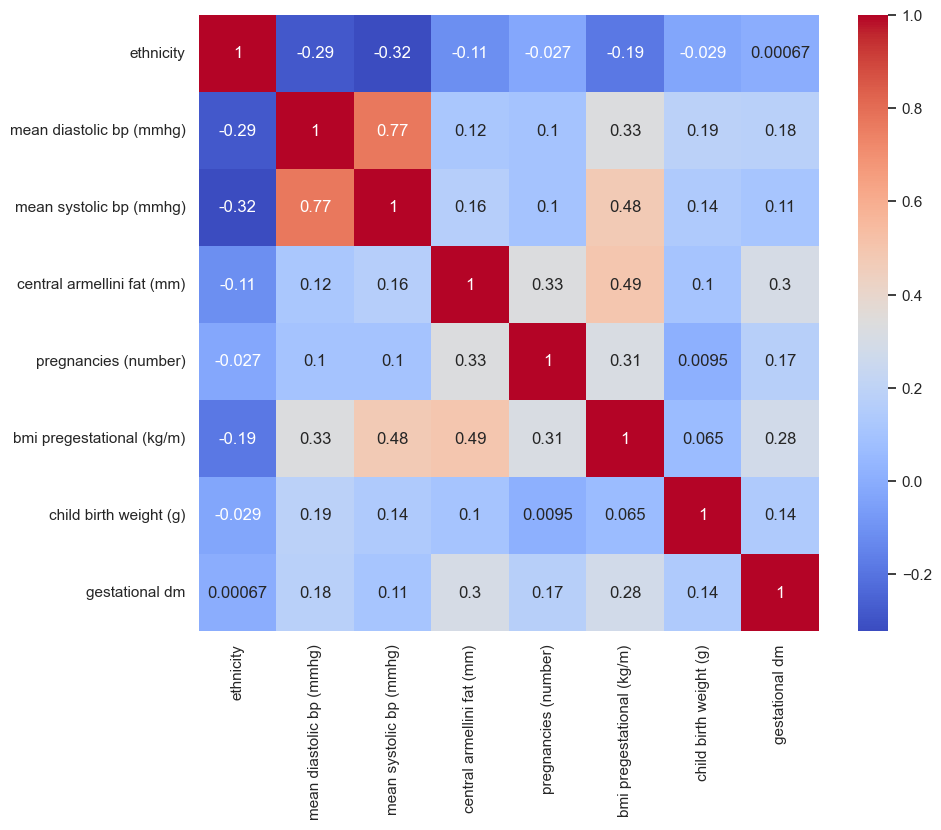

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

*Observaciones:*

- **Presión Arterial Sistólica vs. Diastólica (0.77):** Es la correlación más alta de la matriz.

- **BMI Pregestacional vs. Grasa Central de Armellini (0.49):** Existe una relación moderada-fuerte. Indica que a mayor indice de masa corporal antes del embarazo, mayor es la acumulación de grasa visceral medida por ultrasonido.

- **Diabetes Gestacional con Grasa de Armellini (0.3) y BMI (0.28):** Estas variables muestran una relación positiva con la presencia de diabetes. La obesidad pregestacional y la grasa visceral son factores de riesgo críticos para el desarrollo de resistencia a la insulina durante el embarazo [2][3].

- **Embarazos (Pregnancies) y BMI/Grasa (0.31 - 0.33):** Se observa que a mayor número de embarazos, tienden a subir estos indicadores. Esto se asocia frecuentemente con la retención de peso postparto acumulada en gestaciones posteriores [4].

- **Etnia y Diabetes Gestacional (0.00067):** Este valor es prácticamente cero. Indica que en este grupo de datos específico, pertenecer a una etnia u otra no influye en absoluto en el riesgo de diabetes.






**Referencias**

[1] Nandy, A., Basu, A., & Ghosh, A. (2021). Robust inference for skewed data in health sciences. Journal Of Applied Statistics, 49(8), 2093-2123. https://doi.org/10.1080/02664763.2021.1891527

[2] Kampmann, U., Ovesen, P. G., Møller, N., & Fuglsang, J. (2021). Extreme insulin resistance during pregnancy: a therapeutic challenge. Endocrinology, diabetes & metabolism case reports, 2021, 20-0191. Advance online publication. https://doi.org/10.1530/EDM-20-0191

[3] Luis, B. R. J., & Blas, H. V. (2016). Medición ultrasonográfica de la grasa visceral y su asociación con factores de riesgo cardiovasculares y metabólicos en restantes con sobrepeso. Dialnet. https://dialnet.unirioja.es/servlet/tesis?codigo=50779 

[4] Torres, L., Fotia Perniciaro, L. M. R., Mendez, I., Malpeli, A., & Kruger, A. L. (2025). Factores asociados a la retención de peso postparto en mujeres que asisten a un hospital público de la Provincia de Buenos Aires [Factors associated with postpartum weight retention in women attending a public hospital in the Province of Buenos Aires]. Revista de la Facultad de Ciencias Medicas (Cordoba, Argentina), 82(2), 271–286. https://doi.org/10.31053/1853.0605.v82.n2.45625

